In [1]:
import os
import numpy as np
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

In [2]:
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7)
atlas_filename = schaefer.maps
masker = NiftiLabelsMasker(
    labels_img=atlas_filename,
    standardize=True,
)

[fetch_atlas_schaefer_2018] Added README.md to /home/wunderlich/nilearn_data
[fetch_atlas_schaefer_2018] Dataset created in /home/wunderlich/nilearn_data/schaefer_2018
[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order.txt ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.nii.gz ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)



In [5]:
bold_path = "/mnt/e/fyassine/ad-early-detection/data/Data-Delcode/Delcode_AD_graph_data/pre-raw/sub-1b6c308bb/ses-01/sub-1b6c308bb_ses-01_task-rest_space-MNI152NLin2009cAsym_res-2_desc-ICAAROMA2Phys1GS_bold_reoriented.nii.gz"

In [6]:
time_series = masker.fit_transform(bold_path)

correlation_measure = ConnectivityMeasure(kind='correlation')
corr_matrix = correlation_measure.fit_transform([time_series])[0]

z_matrix = np.arctanh(corr_matrix)
np.fill_diagonal(z_matrix, 0)  # Diagonale bereinigen (inf zu 0)

/tmp/ipykernel_868566/1178084809.py:6: RuntimeWarning: divide by zero encountered in arctanh
  z_matrix = np.arctanh(corr_matrix)


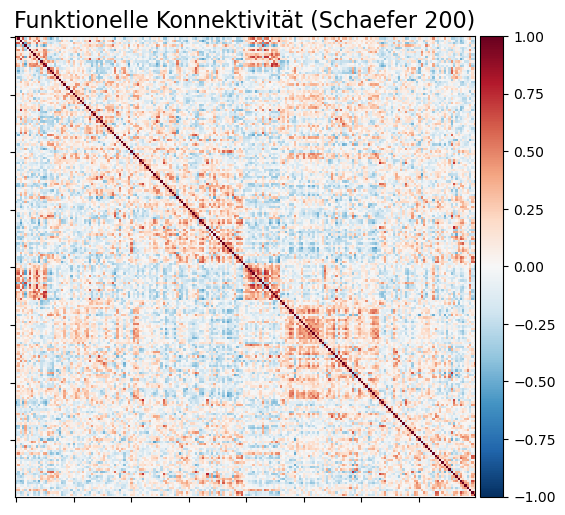

(200, 200)


In [9]:
plotting.plot_matrix(
    corr_matrix,
    vmin=-1, vmax=1,        # Skala von -1 bis 1 festlegen
    cmap='RdBu_r',          # Blau für negative, Rot für positive Korrelationen
    title="Funktionelle Konnektivität (Schaefer 200)",
    colorbar=True
)

plotting.show()
print(corr_matrix.shape)